# *Author: Victor Diallen*

## Importing Libraries

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

## Loading Dataset

In [4]:
# Taking a quick look through the dataset

df = pd.read_csv(r'C:\Users\Victor\Desktop\Python\movies.csv')
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


## Checking and Manipulating Data

In [89]:
# Checking to see if there's any missing data

for col in df.columns:
    missing = np.mean(df[col].isnull())       ## If you don't use the round function, you'll be able to see there actually is missing data
    print('{} - {}%'.format(col, missing))

name - 0.0%
rating - 0.010041731872717789%
genre - 0.0%
year - 0.0%
released - 0.0002608242044861763%
score - 0.0003912363067292645%
votes - 0.0003912363067292645%
director - 0.0%
writer - 0.0003912363067292645%
star - 0.00013041210224308815%
country - 0.0003912363067292645%
budget - 0.2831246739697444%
gross - 0.02464788732394366%
company - 0.002217005738132499%
runtime - 0.0005216484089723526%


In [5]:
# Dropping NA values

df = df.dropna()

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5421 entries, 0 to 7652
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      5421 non-null   object 
 1   rating    5421 non-null   object 
 2   genre     5421 non-null   object 
 3   year      5421 non-null   int64  
 4   released  5421 non-null   object 
 5   score     5421 non-null   float64
 6   votes     5421 non-null   Int64  
 7   director  5421 non-null   object 
 8   writer    5421 non-null   object 
 9   star      5421 non-null   object 
 10  country   5421 non-null   object 
 11  budget    5421 non-null   Int64  
 12  gross     5421 non-null   Int64  
 13  company   5421 non-null   object 
 14  runtime   5421 non-null   Int64  
dtypes: Int64(4), float64(1), int64(1), object(9)
memory usage: 827.8+ KB


In [91]:
# Change data types for better understanding and dropping any possible duplicates

df['budget'] = df['budget'].astype('Int64')
df['gross'] = df['gross'].astype('Int64')
df['votes'] = df['votes'].astype('Int64')
df['runtime'] = df['runtime'].astype('Int64')
df = df.drop_duplicates()

In [21]:
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000,<NA>,NaN,90
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,<NA>,<NA>,Cactus Blue Entertainment,90
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750,<NA>,Embi Productions,<NA>
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,<NA>,James Randall,James Randall,Christina Roz,United States,15000,<NA>,NaN,120


## ------------------------------------------------------------------------------------------------------------------------- ##

In [6]:
# Order data by budget

df = df.sort_values(by=['budget'], inplace=False, ascending=False)

## ------------------------------------------------------------------------------------------------------------------------- ##

In [92]:
# Checking different types of correlation (Pearson (default), Kendall, Spearman) between all numeric columns

corr_pearson = df.corr()
corr_kendall = df.corr(method='kendall')
corr_spearman = df.corr(method='spearman')

In [72]:
corr_pearson

,year,score,votes,budget,gross,runtime
year,1.000000,0.097995,0.222945,0.329321,0.257486,0.120811
score,0.097995,1.000000,0.409182,0.076254,0.186258,0.399451
votes,0.222945,0.409182,1.000000,0.442429,0.630757,0.309212
budget,0.329321,0.076254,0.442429,1.000000,0.740395,0.320447
gross,0.257486,0.186258,0.630757,0.740395,1.000000,0.245216
runtime,0.120811,0.399451,0.309212,0.320447,0.245216,1.000000


In [73]:
corr_kendall

,year,score,votes,budget,gross,runtime
year,1.000000,0.067652,0.331465,0.224120,0.200618,0.097184
score,0.067652,1.000000,0.300115,-0.000566,0.086046,0.283611
votes,0.331465,0.300115,1.000000,0.353702,0.548899,0.198240
budget,0.224120,-0.000566,0.353702,1.000000,0.512637,0.235483
gross,0.200618,0.086046,0.548899,0.512637,1.000000,0.168933
runtime,0.097184,0.283611,0.198240,0.235483,0.168933,1.000000


In [74]:
corr_spearman

,year,score,votes,budget,gross,runtime
year,1.000000,0.099045,0.469829,0.317336,0.293084,0.142977
score,0.099045,1.000000,0.428138,-0.001403,0.126116,0.399857
votes,0.469829,0.428138,1.000000,0.502466,0.742050,0.290159
budget,0.317336,-0.001403,0.502466,1.000000,0.693670,0.336370
gross,0.293084,0.126116,0.742050,0.693670,1.000000,0.246243
runtime,0.142977,0.399857,0.290159,0.336370,0.246243,1.000000


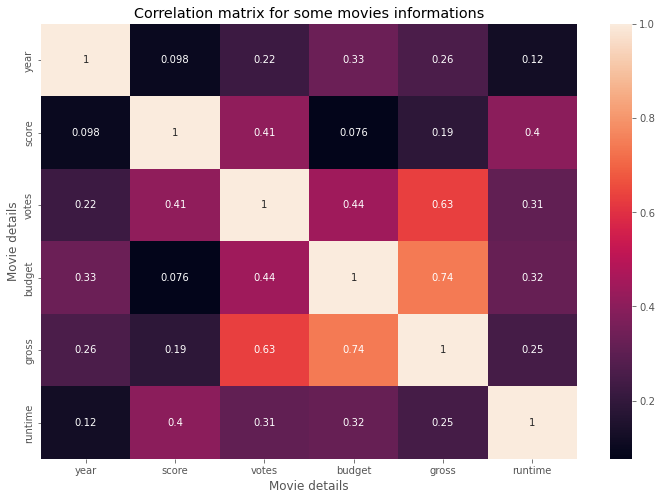

In [75]:
# Ploting a heatmap for a better view of the correlation

matrix = df.corr()

sns.heatmap(matrix, annot = True)

plt.title("Correlation matrix for some movies informations")

plt.xlabel("Movie details")

plt.ylabel("Movie details")

plt.show()

## ------------------------------------------------------------------------------------------------------------------------- ##

In [93]:
# In order to analyze more correlations including informations such as writers, we need to factorize the dataset

correlation_mat = df.apply(lambda x: x.factorize()[0]).corr()

corr_pairs = correlation_mat.unstack()

print(corr_pairs)

name      name        1.000000
          rating      0.169808
          genre       0.028413
          year        0.965461
          released    0.966086
          score      -0.020083
          votes       0.297305
          director    0.725411
          writer      0.791872
          star        0.695124
          country     0.098110
          budget      0.288955
          gross       0.967925
          company     0.535369
          runtime     0.048980
rating    name        0.169808
          rating      1.000000
          genre      -0.116507
          year        0.179456
          released    0.171063
          score       0.036114
          votes       0.097619
          director    0.096014
          writer      0.128909
          star        0.115694
          country    -0.004547
          budget      0.203698
          gross       0.172703
          company    -0.026286
          runtime     0.032265
genre     name        0.028413
          rating     -0.116507
        

## ------------------------------------------------------------------------------------------------------------------------- ##

In [94]:
# Selecting correlations higher than 0.5

sorted_pairs = corr_pairs.sort_values(kind="quicksort")
strong_pairs = sorted_pairs[abs(sorted_pairs) > 0.5]

## Displaying all information

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(strong_pairs)

company   name        0.535369
name      company     0.535369
company   year        0.537731
year      company     0.537731
gross     company     0.545924
company   gross       0.545924
released  company     0.546033
company   released    0.546033
star      writer      0.626647
writer    star        0.626647
director  star        0.636705
star      director    0.636705
          name        0.695124
name      star        0.695124
director  writer      0.717990
writer    director    0.717990
star      year        0.719373
year      star        0.719373
released  star        0.720076
star      released    0.720076
          gross       0.720811
gross     star        0.720811
director  name        0.725411
name      director    0.725411
director  year        0.747785
year      director    0.747785
director  released    0.750825
released  director    0.750825
director  gross       0.751737
gross     director    0.751737
writer    name        0.791872
name      writer      0.791872
writer  

## ------------------------------------------------------------------------------------------------------------------------- ##

In [110]:
# Selecting the top 15 companies by gross revenue

CompanyGrossSum = df.groupby('company')[["gross"]].sum()

CompanyGrossSumSorted = CompanyGrossSum.sort_values('gross', ascending = False)[:15]

CompanyGrossSumSorted

,gross
company,
Warner Bros.,54610959970
Universal Pictures,51241105418
Columbia Pictures,42356430218
Paramount Pictures,40021704691
Twentieth Century Fox,39542573303
Walt Disney Pictures,35833650748
New Line Cinema,19612851164
Marvel Studios,15065592411
DreamWorks Animation,11873612858


In [114]:
# Selecting the top 15 writers by their highest scores

CompanyGrossSum = df.groupby('writer')[["score"]].max()

CompanyGrossSumSorted = CompanyGrossSum.sort_values('score', ascending = False)[:15]

CompanyGrossSumSorted

,score
writer,
Stephen King,9.3
Jonathan Nolan,9.0
Thomas Keneally,8.9
J.R.R. Tolkien,8.9
Quentin Tarantino,8.9
Christopher Nolan,8.8
Winston Groom,8.8
Chuck Palahniuk,8.8
Lilly Wachowski,8.7


## ------------------------------------------------------------------------------------------------------------------------- ##

## Plotting fun

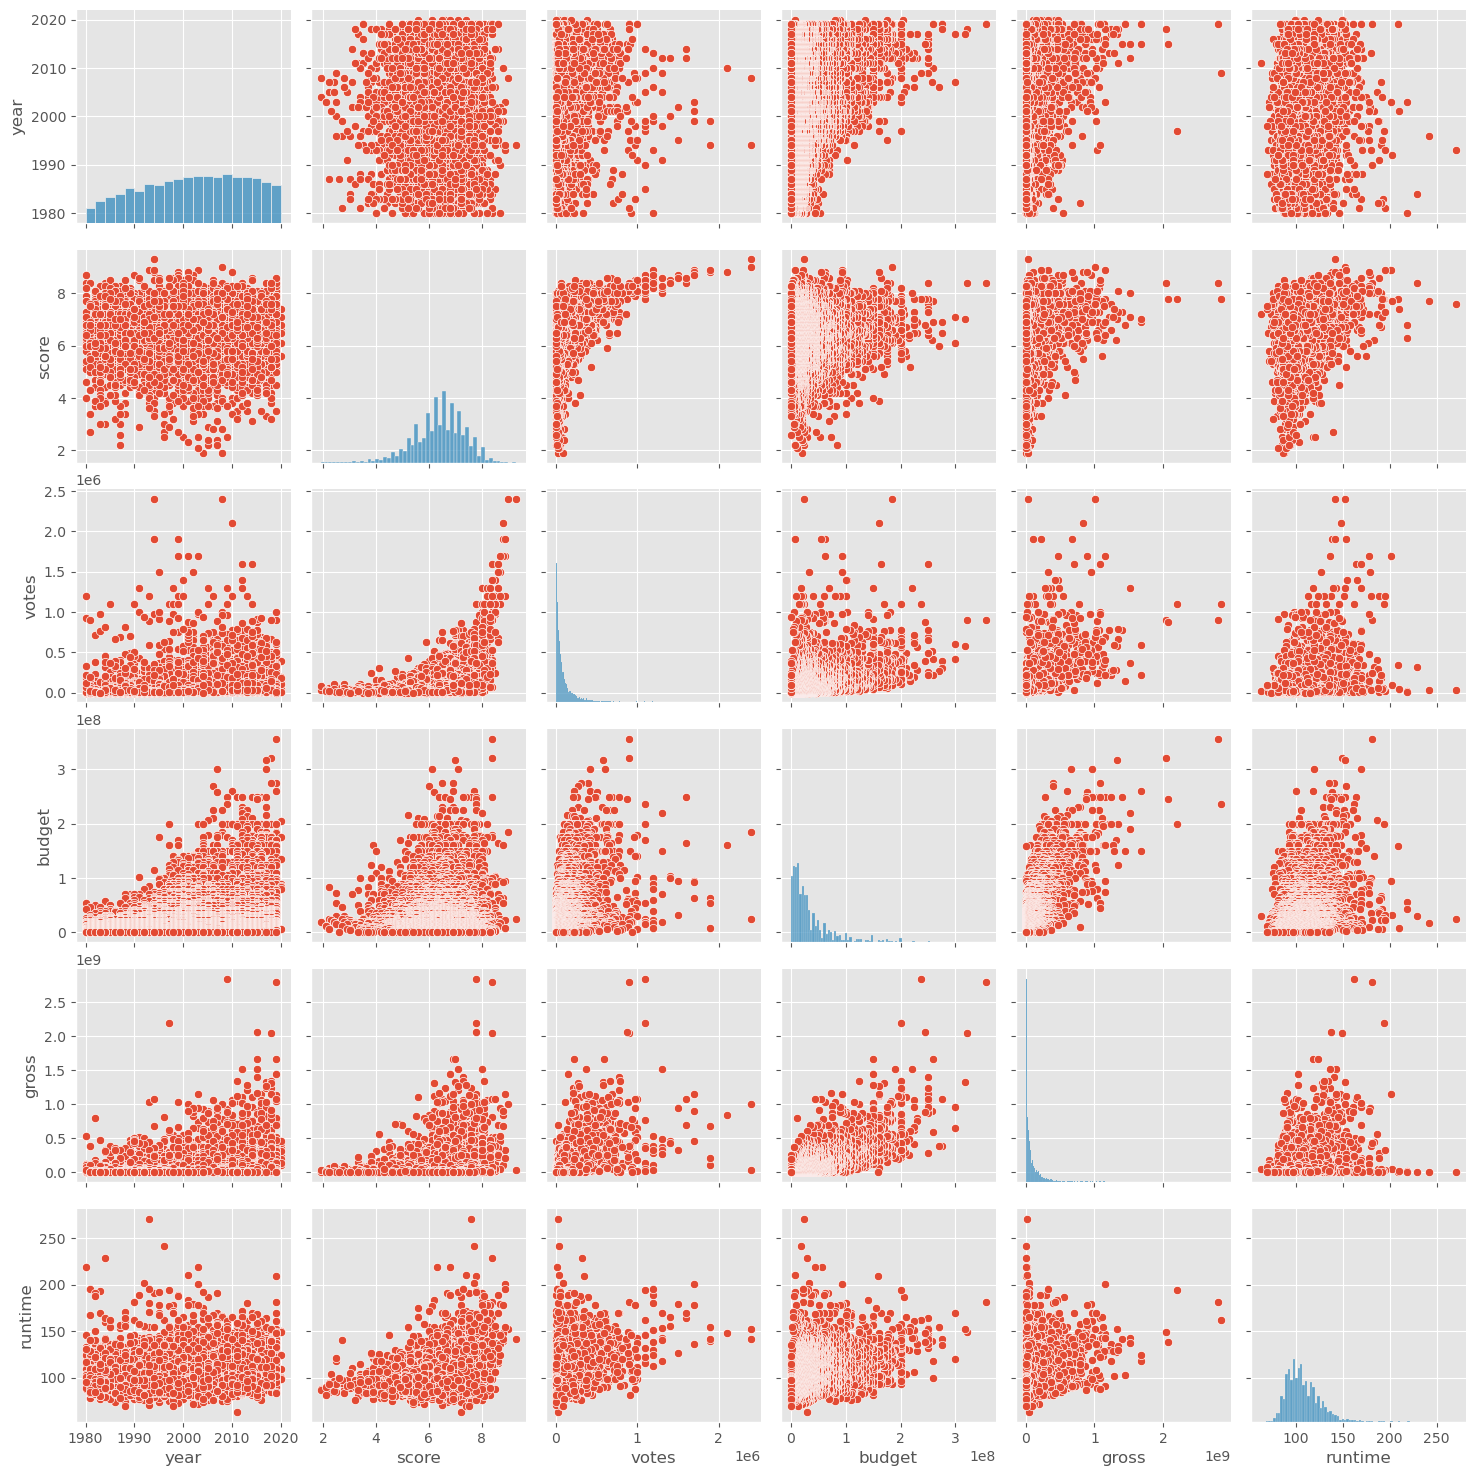

In [178]:
sns.pairplot(df)

<AxesSubplot:xlabel='rating', ylabel='gross'>

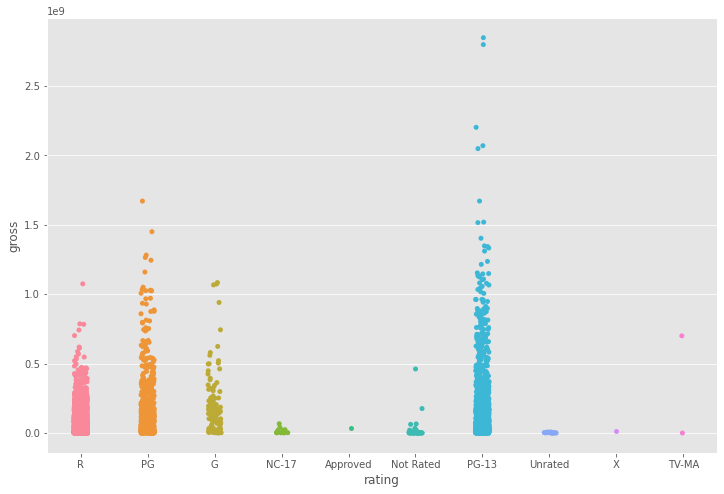

In [99]:
# Gross revenue x ratings

sns.stripplot(x="rating", y="gross", data=df)

[Text(0.5, 0, 'Gross Earnings'),
 Text(0, 0.5, 'Budget for Film'),
 Text(0.5, 1.0, 'Budget x Gross')]

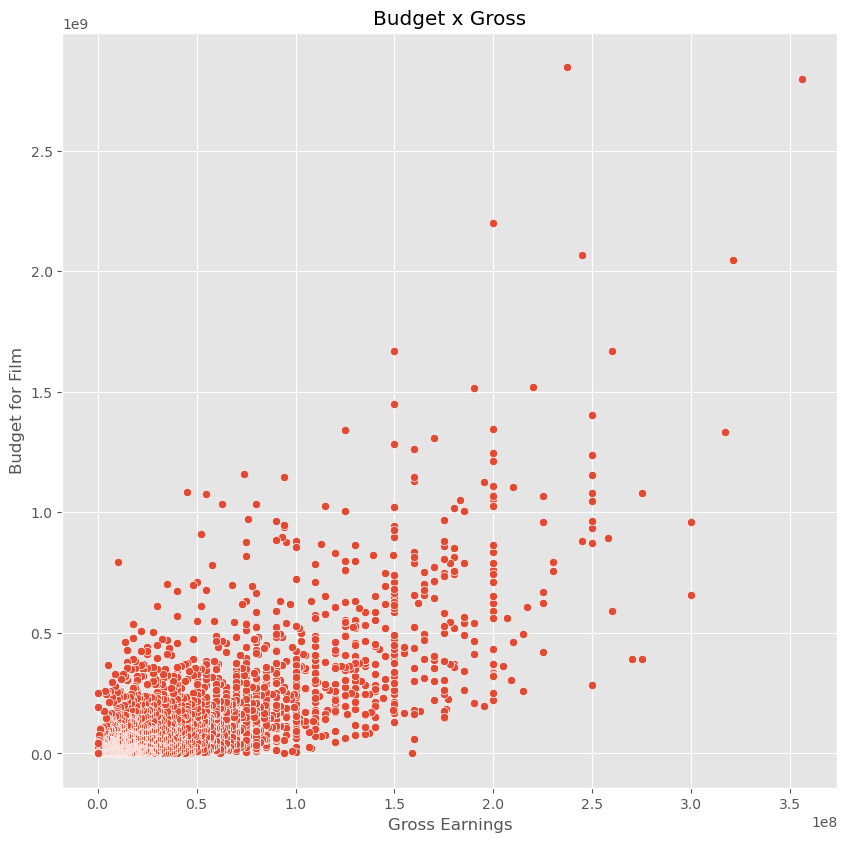

In [181]:
sns.scatterplot(data=df, x='budget', y='gross').set(xlabel='Gross Earnings', ylabel='Budget for Film', title='Budget x Gross')

[Text(0.5, 0, 'Gross Earnings'),
 Text(0, 0.5, 'Budget for Film'),
 Text(0.5, 1.0, 'Budget x Gross')]

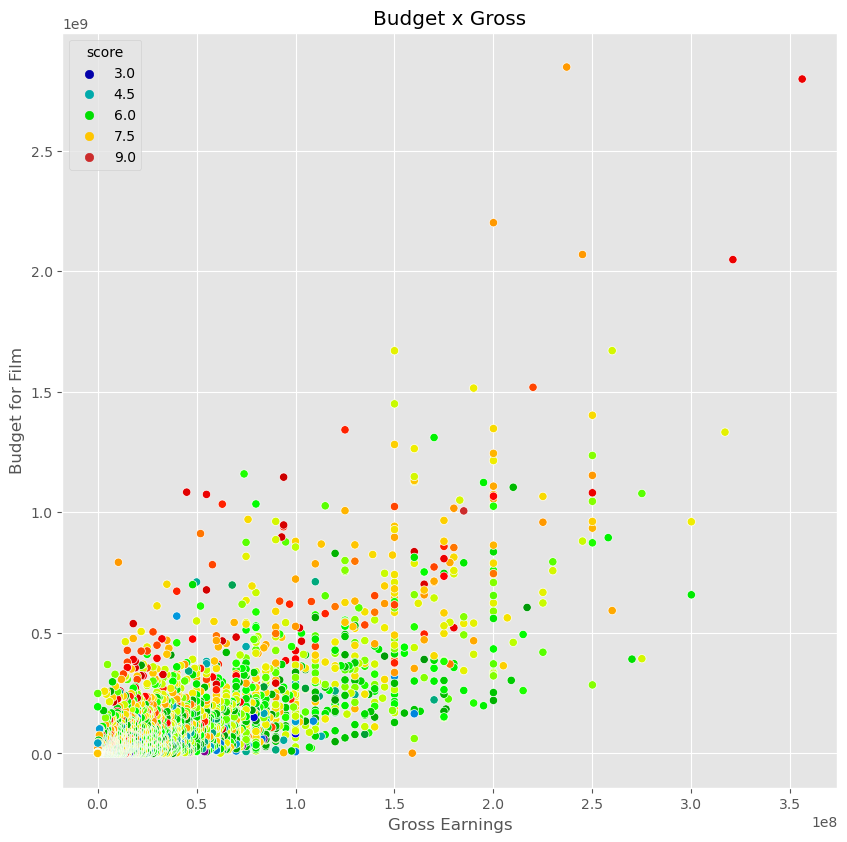

In [186]:
sns.scatterplot(data=df, x='budget', y='gross', hue='score', palette='nipy_spectral').set(xlabel='Gross Earnings', ylabel='Budget for Film', title='Budget x Gross')

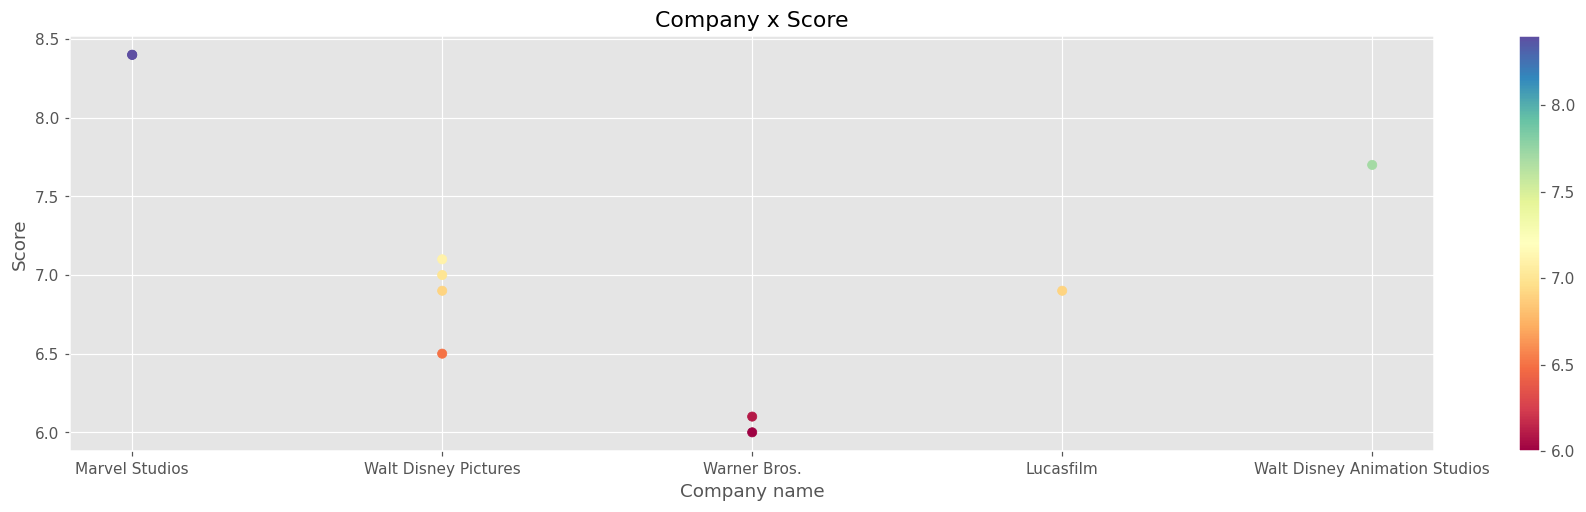

In [216]:
df_score = df.sort_values(by=['score'], inplace=False, ascending=False)
plt.rcParams.update({'figure.figsize':(20,5), 'figure.dpi':110})
plt.scatter(df['company'].head(10), df['score'].head(10), c=df['score'].head(10), cmap='Spectral')
plt.colorbar()
plt.title('Company x Score')
plt.xlabel('Company name')
plt.ylabel('Score')
plt.show()

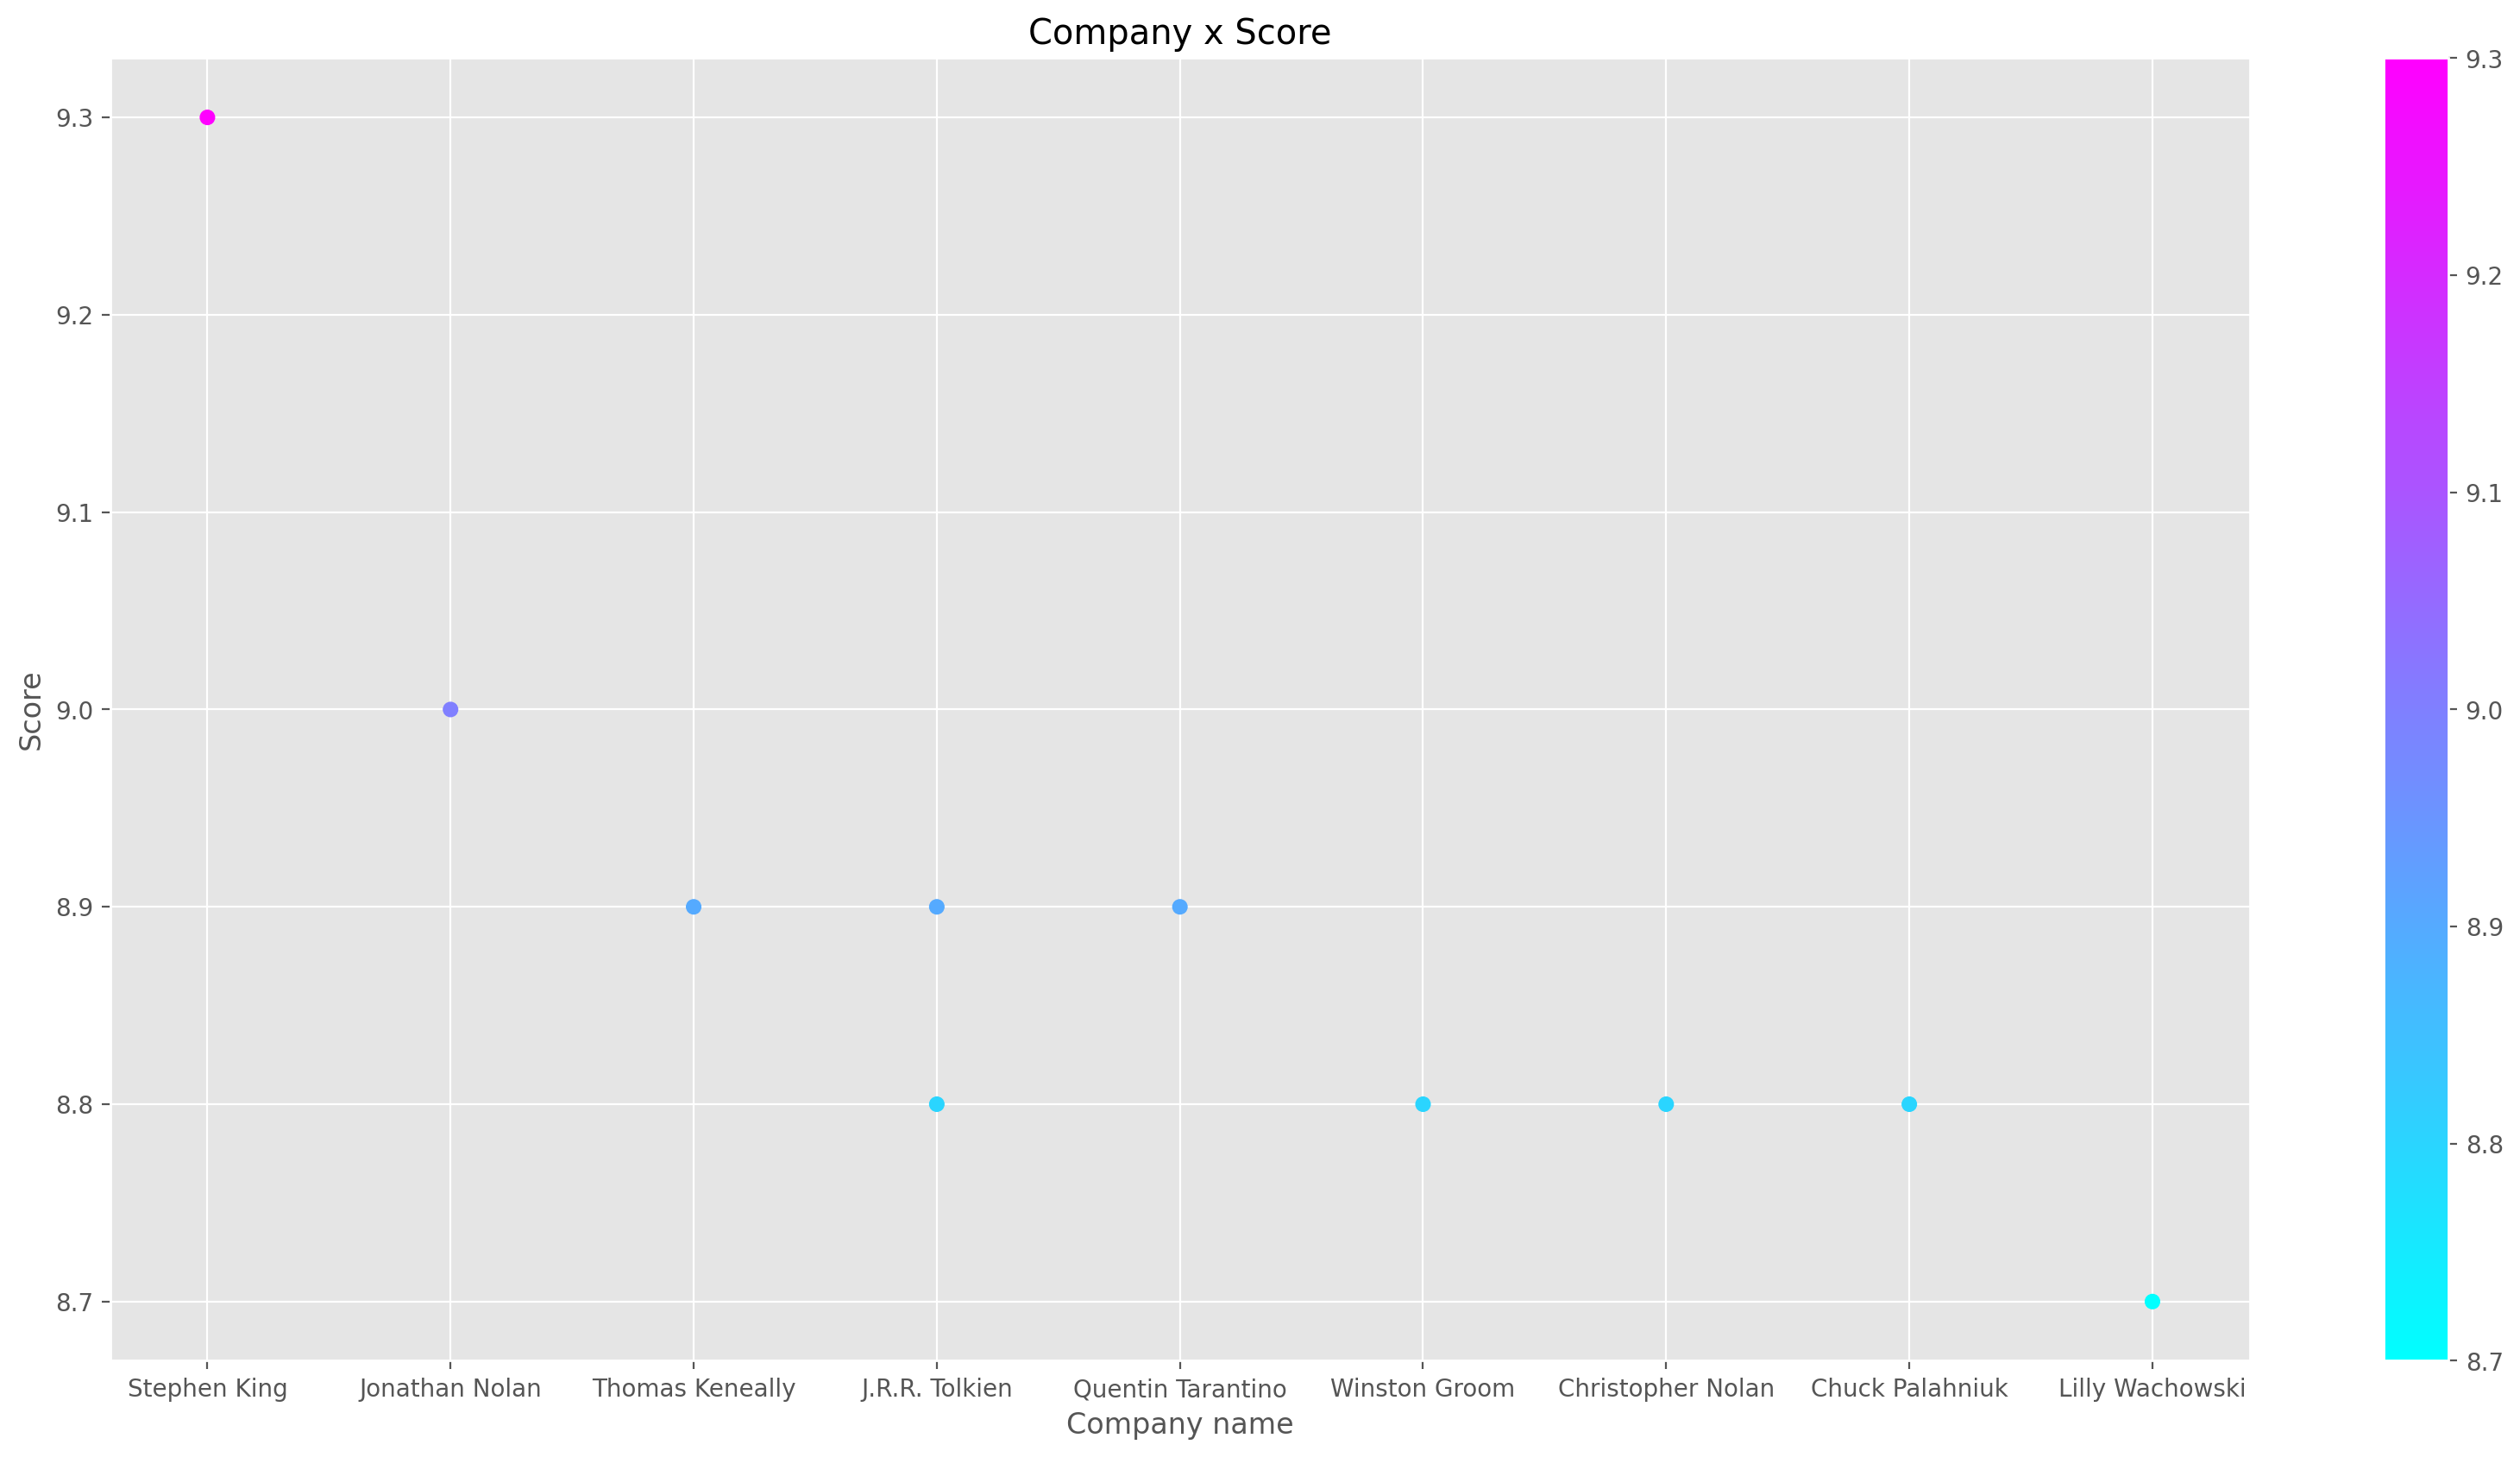

In [9]:
df_score = df.sort_values(by=['score'], inplace=False, ascending=False)
plt.rcParams.update({'figure.figsize':(20,10), 'figure.dpi':200})
plt.scatter(df_score['writer'].head(10), df_score['score'].head(10), c=df_score['score'].head(10), cmap='cool')
plt.colorbar()
plt.title('Company x Score')
plt.xlabel('Company name')
plt.ylabel('Score')
plt.show()